In [ ]:
import numpy as np
import torch
import torch.nn as nn
import imageio.v3 as iio
import numpy as np
import plotly.graph_objects as go

%load_ext autoreload
%autoreload 2


import os
from torch.utils.data import Dataset
import glob
import logging
from torchvision import transforms
from typing import Tuple
import rawpy
import imageio.v3 as iio
import cv2

logging.basicConfig(
    level=logging.INFO, format="[%(asctime)s] [%(levelname)s] %(message)s"
)
logger = logging.getLogger(__name__)


class LinearImageDataset(Dataset):
    def __init__(self, dir, format="tiff", resize: Tuple[int, int] = None):
        self.dir = dir
        self.imgs = glob.glob(os.path.join(self.dir, f"*.{format}"))
        self.num_imgs = len(self.imgs)

        self.resize = None
        if resize:
            self.resize = transforms.Resize(resize)

        logger.info(f"Found {self.num_imgs} images in {self.dir}")

    def __len__(self):
        return self.num_imgs

    def __getitem__(self, idx):
        img = iio.imread(self.imgs[idx])
        return img

    def get_linear(self, idx):
        pass

    def get_log(self, idx):
        pass

    def visualize(self, idx):
        pass


In [5]:
ds = LinearImageDataset(dir="data/RAWAE")
print(ds.imgs)

[2025-11-21 02:16:20,017] [INFO] Found 6 images in data/RAWAE


['data/RAWAE/raw_maxwell_2023_05_26_ - 000225.tiff', 'data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff', 'data/RAWAE/raw_maxwell_2023_05_26_ - 000684.tiff', 'data/RAWAE/raw_maxwell_2023_05_26_ - 001133.tiff', 'data/RAWAE/raw_maxwell_2023_05_26_ - 001026.tiff', 'data/RAWAE/raw_maxwell_2023_05_26_ - 001123.tiff']


In [ ]:
import numpy as np
import plotly.graph_objects as go

img_idx = -1
img = ds[img_idx].astype(np.float32)
print(ds.imgs[img_idx])

r = img[..., 0].flatten()
g = img[..., 1].flatten()
b = img[..., 2].flatten()

# Subsample for performance
N = 100000
if r.size > N:
    idx = np.random.choice(r.size, N, replace=False)
    r, g, b = r[idx], g[idx], b[idx]

# Color markers (original RGB scaled 0-255)
colors = [
    "rgb({},{},{})".format(
        int(np.clip(ri / 65535.0 * 255, 0, 255)),
        int(np.clip(gi / 65535.0 * 255, 0, 255)),
        int(np.clip(bi / 65535.0 * 255, 0, 255)),
    )
    for ri, gi, bi in zip(r, g, b)
]

# Log positions
r_pos = np.where(r > 0, np.log(r), 0.0)
g_pos = np.where(g > 0, np.log(g), 0.0)
b_pos = np.where(b > 0, np.log(b), 0.0)

# 3D scatter plot
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=r_pos,
            y=g_pos,
            z=b_pos,
            mode="markers",
            marker=dict(size=2, color=colors, opacity=1.0),
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title="log(Red)", yaxis_title="log(Green)", zaxis_title="log(Blue)"
    ),
    title="3D RGB Scatter Plot (log-scaled positions, original colors)",
)

fig.show()

data/RAWAE/raw_maxwell_2023_05_26_ - 001123.tiff


In [7]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt


def show_linear_image(img, gamma=1 / 2.2):
    """
    Display a 16-bit linear RGB image using matplotlib."

    Args:
        img_path (str): Path to the 16-bit image (TIFF, linear RGB).
        gamma (float): Optional gamma correction for visualization.
    """
    # Load 16-bit image
    img = img.astype(np.float32)

    # Normalize 0-1 based on 16-bit range
    img_norm = img / 65535.0

    # Apply gamma correction (optional)
    img_gamma = np.power(img_norm, gamma)

    # Display with matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(img_gamma)
    plt.axis("off")
    plt.title("16-bit Linear Image Visualization")
    plt.show()


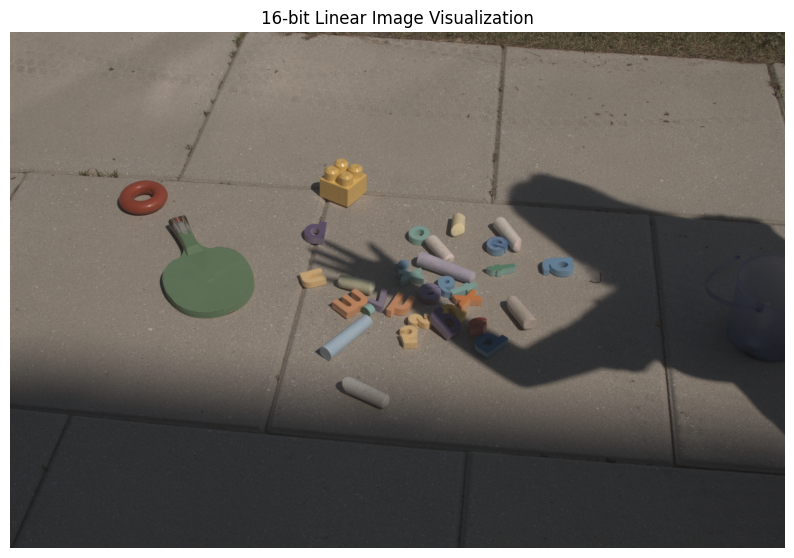

In [8]:
show_linear_image(ds[-1])

[2025-11-21 02:22:03,283] [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.006767598..1.0465037].


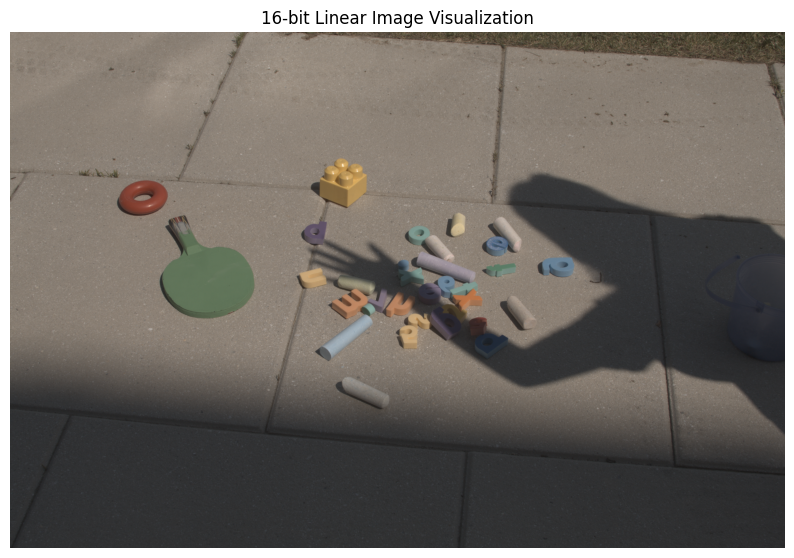

In [19]:
y = ds[-1].astype(np.float32)
non_zero_mask = y > 0
y[non_zero_mask] = np.log(y[non_zero_mask])
y += 0.1
new_y = np.exp(y)
show_linear_image(new_y)